<a href="https://colab.research.google.com/github/Leanhchudang2511/baitaptrituenhantao/blob/main/BTVN2.11-2.14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   KET QUA HE THONG GIA GRAB-BIKE
  Quang duong  : 12 km
  Luu luong GT : 75%
  Muc cau      : 80%
  Thoi tiet    : 80/100 (0=tot,100=xau)
  Danh gia KH  : 4.2 sao
  Dung gio     : 65%

  >> Gia di xe  : 76.7 / 100
  >> Diem thuong: 85.5 / 100


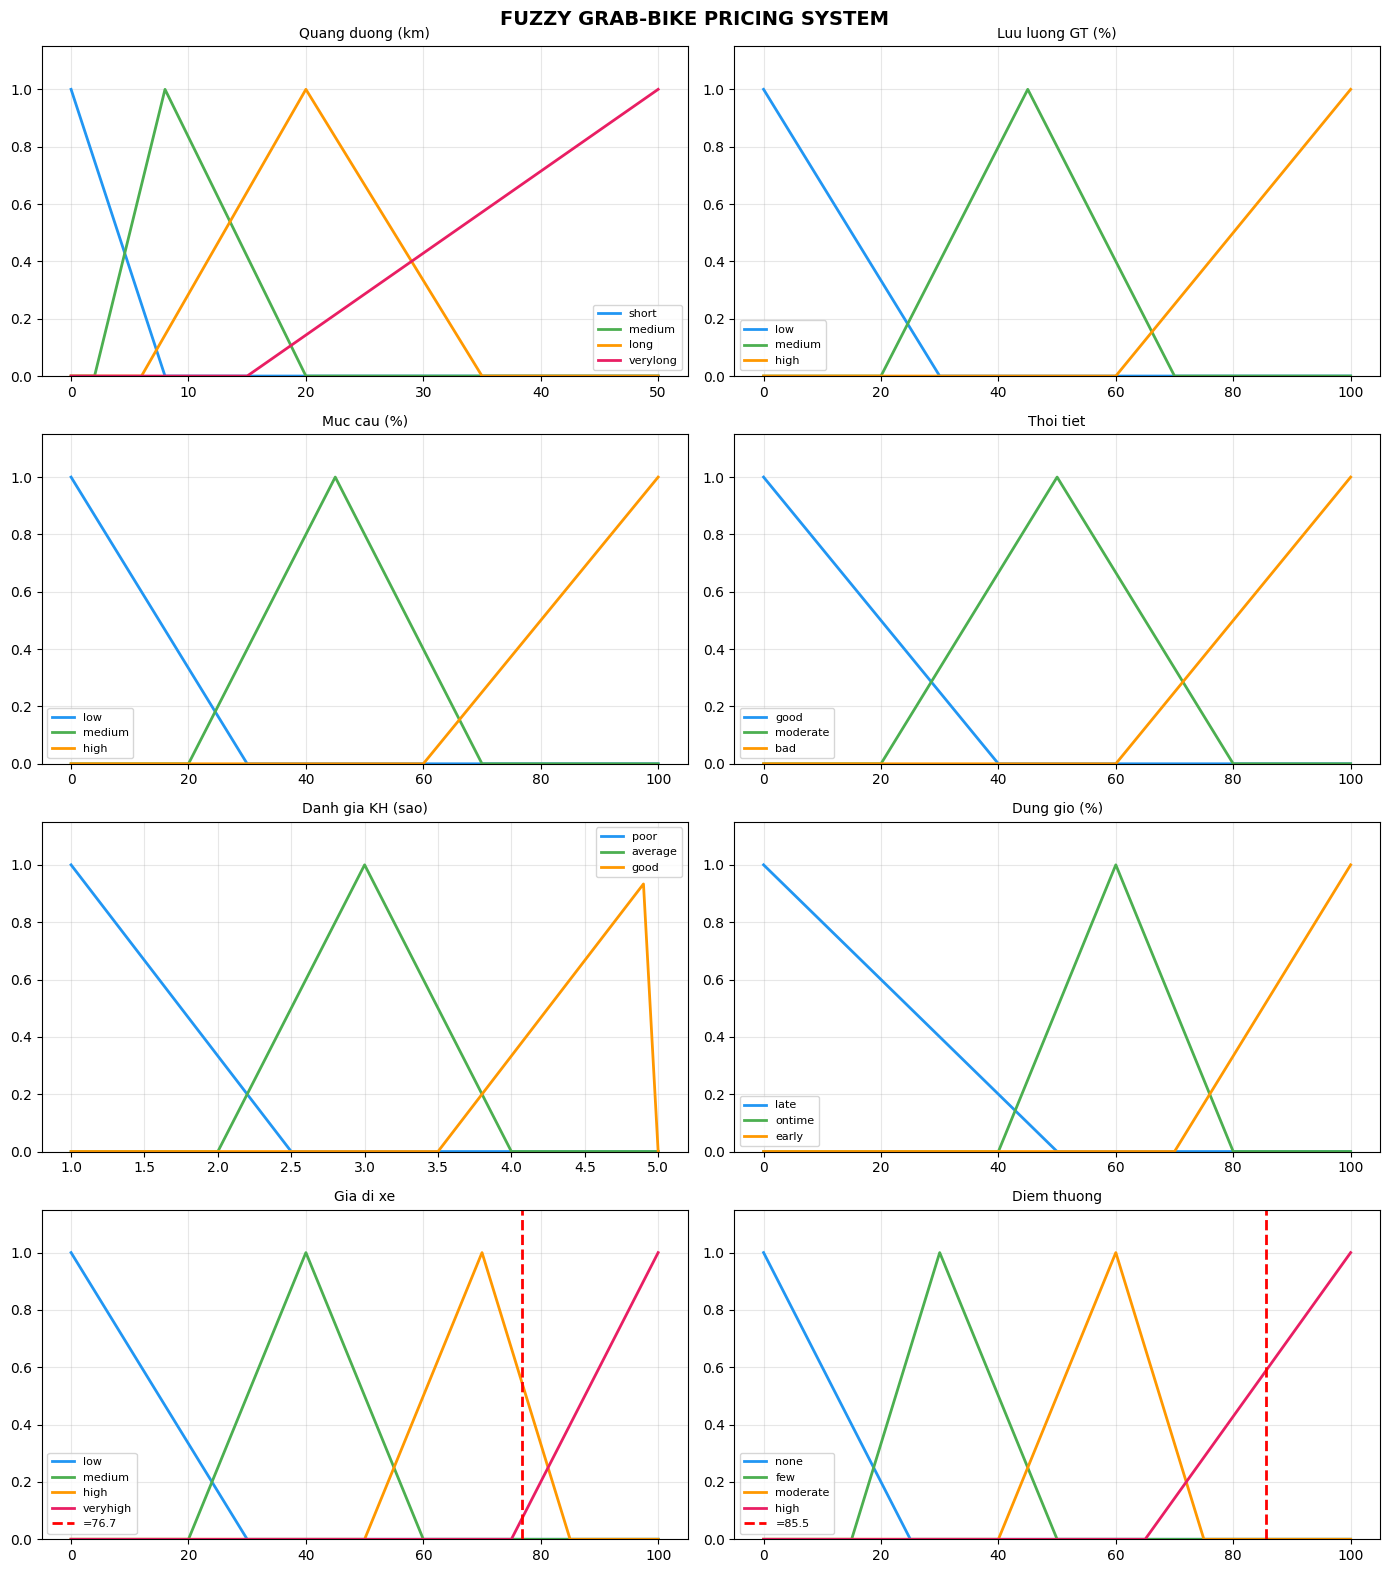

In [2]:
!pip install scikit-fuzzy -q
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

distance    = ctrl.Antecedent(np.arange(0, 51, 1),   'distance')
traffic     = ctrl.Antecedent(np.arange(0, 101, 1),  'traffic')
demand      = ctrl.Antecedent(np.arange(0, 101, 1),  'demand')
weather     = ctrl.Antecedent(np.arange(0, 101, 1),  'weather')
rating      = ctrl.Antecedent(np.arange(1, 5.1, 0.1),'rating')
punctuality = ctrl.Antecedent(np.arange(0, 101, 1),  'punctuality')

price = ctrl.Consequent(np.arange(0, 101, 1), 'price')
bonus = ctrl.Consequent(np.arange(0, 101, 1), 'bonus')

distance['short']    = fuzz.trimf(distance.universe, [0,  0,  8])
distance['medium']   = fuzz.trimf(distance.universe, [2,  8, 20])
distance['long']     = fuzz.trimf(distance.universe, [6, 20, 35])
distance['verylong'] = fuzz.trimf(distance.universe, [15,50, 50])

traffic['low']    = fuzz.trimf(traffic.universe, [0,  0,  30])
traffic['medium'] = fuzz.trimf(traffic.universe, [20,45,  70])
traffic['high']   = fuzz.trimf(traffic.universe, [60,100,100])

demand['low']    = fuzz.trimf(demand.universe, [0,  0,  30])
demand['medium'] = fuzz.trimf(demand.universe, [20,45,  70])
demand['high']   = fuzz.trimf(demand.universe, [60,100,100])

weather['good']     = fuzz.trimf(weather.universe, [0,  0,  40])
weather['moderate'] = fuzz.trimf(weather.universe, [20,50,  80])
weather['bad']      = fuzz.trimf(weather.universe, [60,100,100])

rating['poor']    = fuzz.trimf(rating.universe, [1.0,1.0,2.5])
rating['average'] = fuzz.trimf(rating.universe, [2.0,3.0,4.0])
rating['good']    = fuzz.trimf(rating.universe, [3.5,5.0,5.0])

punctuality['late']   = fuzz.trimf(punctuality.universe, [0,  0, 50])
punctuality['ontime'] = fuzz.trimf(punctuality.universe, [40,60, 80])
punctuality['early']  = fuzz.trimf(punctuality.universe, [70,100,100])

price['low']      = fuzz.trimf(price.universe, [0,  0,  30])
price['medium']   = fuzz.trimf(price.universe, [20,40,  60])
price['high']     = fuzz.trimf(price.universe, [50,70,  85])
price['veryhigh'] = fuzz.trimf(price.universe, [75,100,100])

bonus['none']     = fuzz.trimf(bonus.universe, [0,  0,  25])
bonus['few']      = fuzz.trimf(bonus.universe, [15,30,  50])
bonus['moderate'] = fuzz.trimf(bonus.universe, [40,60,  75])
bonus['high']     = fuzz.trimf(bonus.universe, [65,100,100])

# ── 20 LUAT MO ──
rules = [
    ctrl.Rule(distance['short']    & traffic['low']    & demand['low'],           price['low']),
    ctrl.Rule(distance['short']    & traffic['medium'] & demand['high'],          price['medium']),
    ctrl.Rule(distance['medium']   & traffic['high']   & demand['high'],          price['high']),
    ctrl.Rule(distance['long']     & traffic['medium'] & weather['good'],         price['medium']),
    ctrl.Rule(distance['long']     & traffic['high']   & weather['bad'],          price['veryhigh']),
    ctrl.Rule(distance['verylong'] & traffic['high']   & demand['high'],          price['veryhigh']),
    ctrl.Rule(distance['medium']   & traffic['low'],                              price['medium']),
    ctrl.Rule(distance['short']    & traffic['low']    & demand['medium'],        price['medium']),
    ctrl.Rule(distance['verylong'] & weather['bad'],                              price['high']),
    ctrl.Rule(distance['medium']   & traffic['medium'] & weather['moderate'],     price['medium']),
    ctrl.Rule(rating['good']       & punctuality['early'],                        bonus['high']),
    ctrl.Rule(rating['average']    & punctuality['ontime'],                       bonus['moderate']),
    ctrl.Rule(rating['poor']       & punctuality['late'],                         bonus['none']),
    ctrl.Rule(distance['long']     & traffic['high']   & punctuality['ontime'],   bonus['high']),
    ctrl.Rule(distance['medium']   & traffic['medium'] & rating['good'],          bonus['moderate']),
    ctrl.Rule(rating['poor']       & punctuality['late'],                         bonus['none']),
    ctrl.Rule(distance['verylong'] & weather['bad']    & rating['good'],          bonus['high']),
    ctrl.Rule(distance['short']    & rating['average'] & punctuality['ontime'],   bonus['few']),
    ctrl.Rule(distance['long']     & traffic['high']   & punctuality['late'],     bonus['few']),
    ctrl.Rule(distance['medium']   & weather['moderate'] & rating['good'],        bonus['moderate']),
]

grab_ctrl = ctrl.ControlSystem(rules)
grab_sim  = ctrl.ControlSystemSimulation(grab_ctrl)

inp_distance    = 12
inp_traffic     = 75
inp_demand      = 80
inp_weather     = 80
inp_rating      = 4.2
inp_punctuality = 65

grab_sim.input['distance']    = inp_distance
grab_sim.input['traffic']     = inp_traffic
grab_sim.input['demand']      = inp_demand
grab_sim.input['weather']     = inp_weather
grab_sim.input['rating']      = inp_rating
grab_sim.input['punctuality'] = inp_punctuality

grab_sim.compute()

out_price = grab_sim.output['price']
out_bonus = grab_sim.output['bonus']

print("=" * 50)
print("   KET QUA HE THONG GIA GRAB-BIKE")
print("=" * 50)
print(f"  Quang duong  : {inp_distance} km")
print(f"  Luu luong GT : {inp_traffic}%")
print(f"  Muc cau      : {inp_demand}%")
print(f"  Thoi tiet    : {inp_weather}/100 (0=tot,100=xau)")
print(f"  Danh gia KH  : {inp_rating} sao")
print(f"  Dung gio     : {inp_punctuality}%")
print(f"\n  >> Gia di xe  : {out_price:.1f} / 100")
print(f"  >> Diem thuong: {out_bonus:.1f} / 100")
print("=" * 50)

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('FUZZY GRAB-BIKE PRICING SYSTEM', fontsize=14, fontweight='bold')

vars_cfg = [
    (distance,    'Quang duong (km)'),
    (traffic,     'Luu luong GT (%)'),
    (demand,      'Muc cau (%)'),
    (weather,     'Thoi tiet'),
    (rating,      'Danh gia KH (sao)'),
    (punctuality, 'Dung gio (%)'),
    (price,       'Gia di xe'),
    (bonus,       'Diem thuong'),
]
clrs = ['#2196F3','#4CAF50','#FF9800','#E91E63']

for ax, (var, title) in zip(axes.flatten(), vars_cfg):
    for i, lbl in enumerate(var.terms):
        ax.plot(var.universe, var[lbl].mf, label=lbl,
                linewidth=2, color=clrs[i % 4])
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.15)

axes[3][0].axvline(x=out_price, color='red', linestyle='--',
                   linewidth=2, label=f'={out_price:.1f}')
axes[3][0].legend(fontsize=8)
axes[3][1].axvline(x=out_bonus, color='red', linestyle='--',
                   linewidth=2, label=f'={out_bonus:.1f}')
axes[3][1].legend(fontsize=8)

plt.tight_layout()
plt.show()

   2.12 – CHIẾT KHẤU SHOPEE
  Xep hang cua hang    : 4.3 sao
  Khoi luong ban hang  : 40%
  Bien loi nhuan       : 55%
  Su kien theo mua     : 80/100
  Chiet khau doi thu   : 60%

  >> Chiet khau de xuat: 17.6%
  >> Muc do           : Trung binh (10-20%)


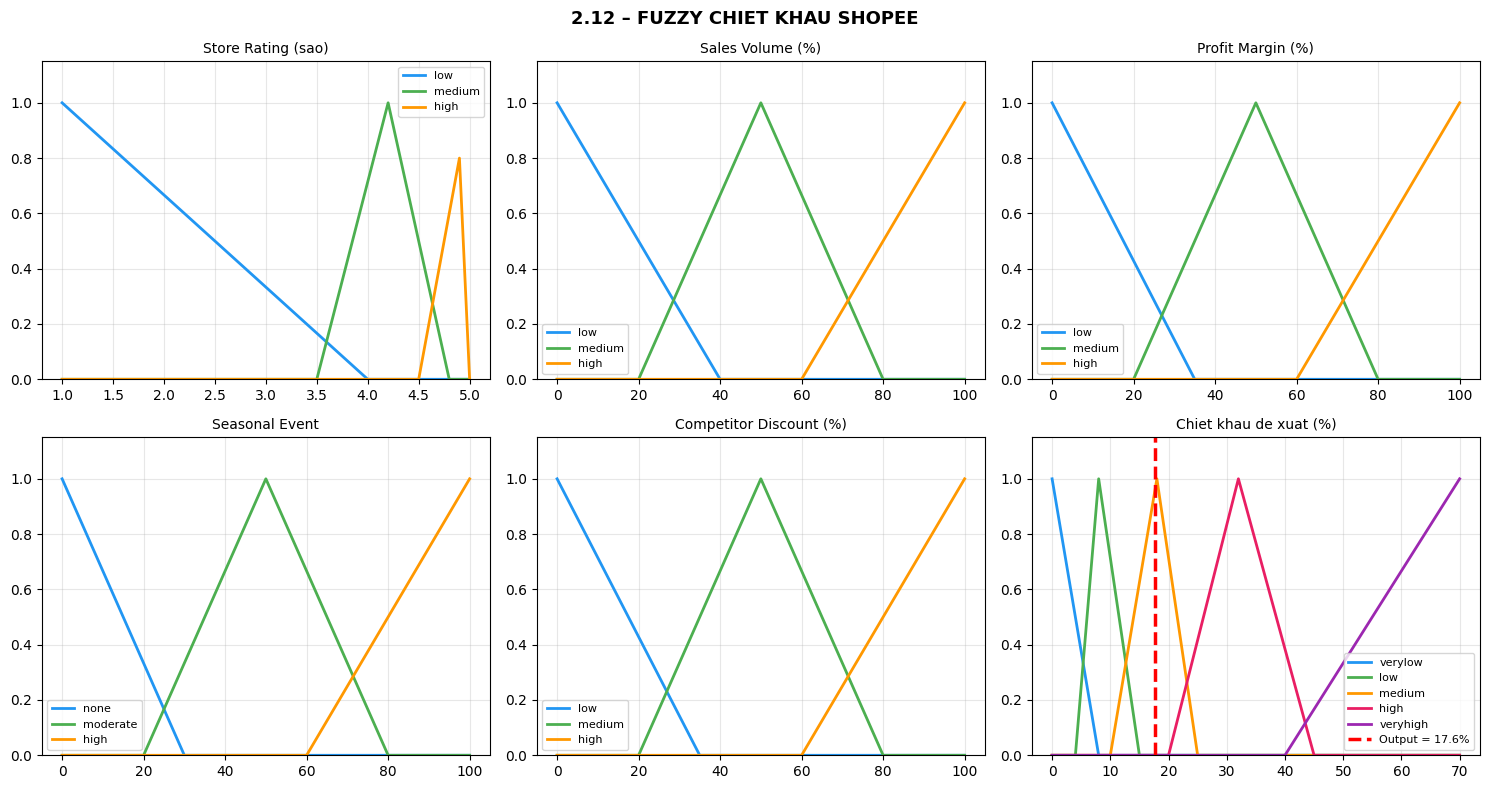

In [4]:
!pip install scikit-fuzzy -q
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

store_rating = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'store_rating')

sales_volume = ctrl.Antecedent(np.arange(0, 101, 1), 'sales_volume')

profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_margin')

seasonal_event = ctrl.Antecedent(np.arange(0, 101, 1), 'seasonal_event')

competitor_dis = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor_dis')

discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

store_rating['low']    = fuzz.trimf(store_rating.universe, [1.0, 1.0, 4.0])
store_rating['medium'] = fuzz.trimf(store_rating.universe, [3.5, 4.2, 4.8])
store_rating['high']   = fuzz.trimf(store_rating.universe, [4.5, 5.0, 5.0])

sales_volume['low']    = fuzz.trimf(sales_volume.universe, [0,  0,  40])
sales_volume['medium'] = fuzz.trimf(sales_volume.universe, [20, 50, 80])
sales_volume['high']   = fuzz.trimf(sales_volume.universe, [60, 100, 100])

profit_margin['low']   = fuzz.trimf(profit_margin.universe, [0,  0,  35])
profit_margin['medium']= fuzz.trimf(profit_margin.universe, [20, 50, 80])
profit_margin['high']  = fuzz.trimf(profit_margin.universe, [60, 100, 100])

seasonal_event['none']    = fuzz.trimf(seasonal_event.universe, [0,  0,  30])
seasonal_event['moderate']= fuzz.trimf(seasonal_event.universe, [20, 50, 80])
seasonal_event['high']    = fuzz.trimf(seasonal_event.universe, [60, 100, 100])

competitor_dis['low']   = fuzz.trimf(competitor_dis.universe, [0,  0,  35])
competitor_dis['medium']= fuzz.trimf(competitor_dis.universe, [20, 50, 80])
competitor_dis['high']  = fuzz.trimf(competitor_dis.universe, [60, 100, 100])

discount['verylow']  = fuzz.trimf(discount.universe, [0,  0,  8])
discount['low']      = fuzz.trimf(discount.universe, [4,  8,  15])
discount['medium']   = fuzz.trimf(discount.universe, [10, 18, 25])
discount['high']     = fuzz.trimf(discount.universe, [20, 32, 45])
discount['veryhigh'] = fuzz.trimf(discount.universe, [40, 70, 70])

rules = [

    ctrl.Rule(store_rating['low']  & profit_margin['high'],                              discount['veryhigh']),


    ctrl.Rule(store_rating['low']  & sales_volume['low']   & profit_margin['high'],      discount['high']),


    ctrl.Rule(seasonal_event['none'] & competitor_dis['low'],                            discount['low']),


    ctrl.Rule(profit_margin['low']  & competitor_dis['low'],                             discount['verylow']),


    ctrl.Rule(seasonal_event['high'] & competitor_dis['high'],                           discount['veryhigh']),


    ctrl.Rule(sales_volume['high']  & profit_margin['high'],                             discount['verylow']),


    ctrl.Rule(store_rating['high']  & profit_margin['medium'] & seasonal_event['high'],  discount['medium']),


    ctrl.Rule(sales_volume['low']   & profit_margin['medium'],                           discount['high']),


    ctrl.Rule(store_rating['medium']& sales_volume['medium'] & profit_margin['medium'],  discount['medium']),


    ctrl.Rule(seasonal_event['high']& profit_margin['high'],                             discount['high']),
]

ctrl212 = ctrl.ControlSystem(rules)
sim212  = ctrl.ControlSystemSimulation(ctrl212)

inp_store_rating  = 4.3
inp_sales_volume  = 40
inp_profit_margin = 55
inp_seasonal_event= 80
inp_competitor_dis= 60

sim212.input['store_rating']   = inp_store_rating
sim212.input['sales_volume']   = inp_sales_volume
sim212.input['profit_margin']  = inp_profit_margin
sim212.input['seasonal_event'] = inp_seasonal_event
sim212.input['competitor_dis'] = inp_competitor_dis
sim212.compute()
out_discount = sim212.output['discount']

print("=" * 55)
print("   2.12 – CHIẾT KHẤU SHOPEE")
print("=" * 55)
print(f"  Xep hang cua hang    : {inp_store_rating} sao")
print(f"  Khoi luong ban hang  : {inp_sales_volume}%")
print(f"  Bien loi nhuan       : {inp_profit_margin}%")
print(f"  Su kien theo mua     : {inp_seasonal_event}/100")
print(f"  Chiet khau doi thu   : {inp_competitor_dis}%")
print(f"\n  >> Chiet khau de xuat: {out_discount:.1f}%")

if out_discount <= 5:
    level = "Rat thap (0-5%)"
elif out_discount <= 10:
    level = "Thap (5-10%)"
elif out_discount <= 20:
    level = "Trung binh (10-20%)"
elif out_discount <= 40:
    level = "Cao (20-40%)"
else:
    level = "Rat cao (40-70%)"
print(f"  >> Muc do           : {level}")
print("=" * 55)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('2.12 – FUZZY CHIET KHAU SHOPEE', fontsize=13, fontweight='bold')
clrs = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

vars_cfg = [
    (store_rating,  'Store Rating (sao)'),
    (sales_volume,  'Sales Volume (%)'),
    (profit_margin, 'Profit Margin (%)'),
    (seasonal_event,'Seasonal Event'),
    (competitor_dis,'Competitor Discount (%)'),
    (discount,      'Chiet khau de xuat (%)'),
]

for ax, (var, title) in zip(axes.flatten(), vars_cfg):
    for i, lbl in enumerate(var.terms):
        ax.plot(var.universe, var[lbl].mf, label=lbl, lw=2, color=clrs[i % 5])
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=.3); ax.set_ylim(0, 1.15)

axes[1][2].axvline(x=out_discount, color='red', linestyle='--', lw=2.5,
                   label=f'Output = {out_discount:.1f}%')
axes[1][2].legend(fontsize=8)

plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.7 MB/s eta 0:00:00
   2.13 – KE HOACH CHIEN LUOC BAN HANG SHOPEE
  Nhu cau san pham     : 70%
  Ap luc canh tranh    : 65%
  Uy tin cua hang      : 4.2 sao
  Bien loi nhuan       : 45%
  Nhu cau theo mua     : 80/100

  >> Muc giam gia de xuat: 31.5%
  >> Muc do            : Cao (20-40%)


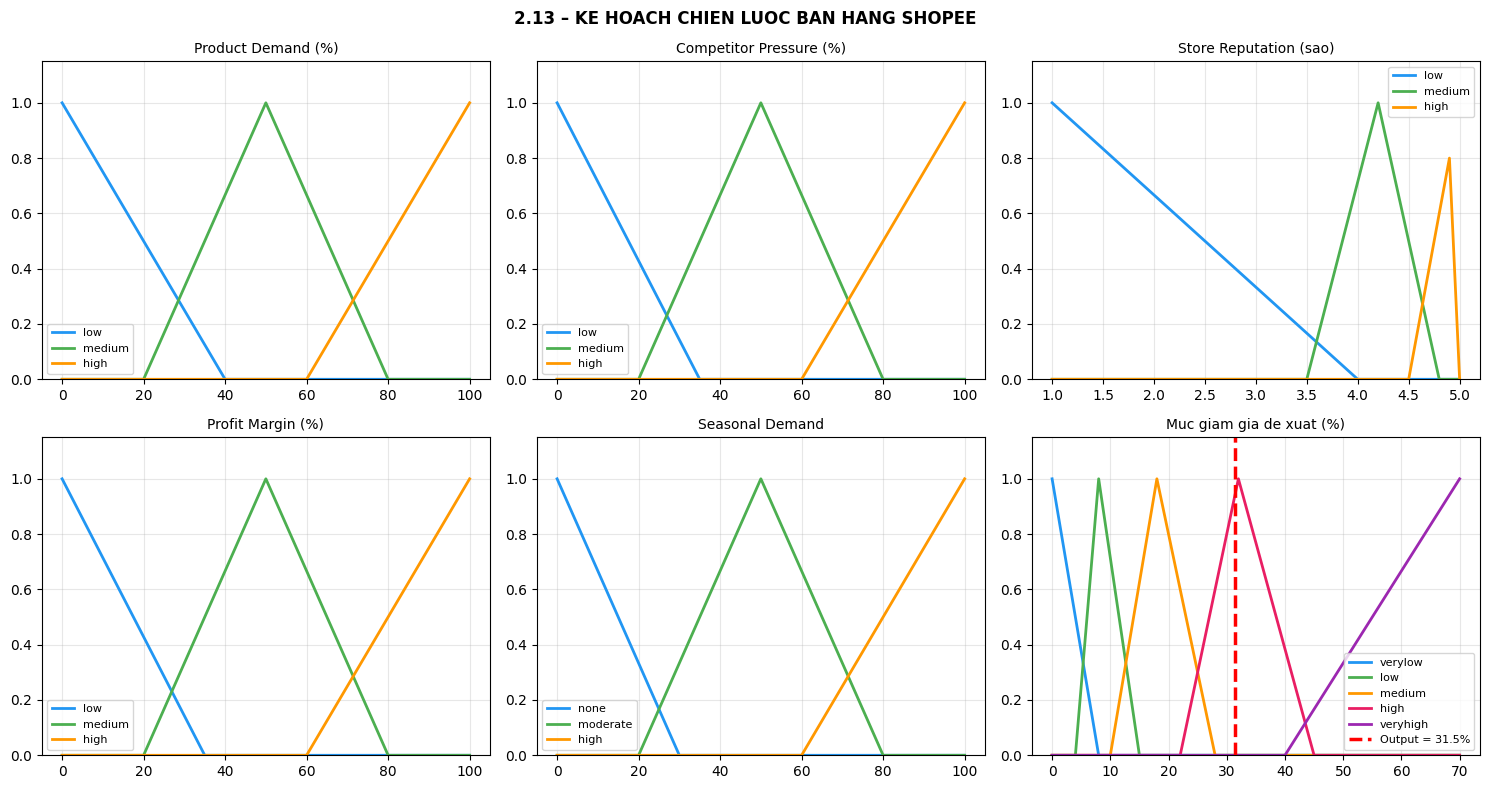

In [1]:

!pip install scikit-fuzzy -q

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

prod_demand = ctrl.Antecedent(np.arange(0, 101, 1), 'prod_demand')

comp_pressure = ctrl.Antecedent(np.arange(0, 101, 1), 'comp_pressure')


store_rep = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'store_rep')


margin = ctrl.Antecedent(np.arange(0, 101, 1), 'margin')


season_demand = ctrl.Antecedent(np.arange(0, 101, 1), 'season_demand')



discount213 = ctrl.Consequent(np.arange(0, 71, 1), 'discount213')

prod_demand['low']    = fuzz.trimf(prod_demand.universe, [0,  0,  40])
prod_demand['medium'] = fuzz.trimf(prod_demand.universe, [20, 50, 80])
prod_demand['high']   = fuzz.trimf(prod_demand.universe, [60, 100, 100])

comp_pressure['low']   = fuzz.trimf(comp_pressure.universe, [0,  0,  35])
comp_pressure['medium']= fuzz.trimf(comp_pressure.universe, [20, 50, 80])
comp_pressure['high']  = fuzz.trimf(comp_pressure.universe, [60, 100, 100])

store_rep['low']   = fuzz.trimf(store_rep.universe, [1.0, 1.0, 4.0])
store_rep['medium']= fuzz.trimf(store_rep.universe, [3.5, 4.2, 4.8])
store_rep['high']  = fuzz.trimf(store_rep.universe, [4.5, 5.0, 5.0])

margin['low']   = fuzz.trimf(margin.universe, [0,  0,  35])
margin['medium']= fuzz.trimf(margin.universe, [20, 50, 80])
margin['high']  = fuzz.trimf(margin.universe, [60, 100, 100])

season_demand['none']    = fuzz.trimf(season_demand.universe, [0,  0,  30])
season_demand['moderate']= fuzz.trimf(season_demand.universe, [20, 50, 80])
season_demand['high']    = fuzz.trimf(season_demand.universe, [60, 100, 100])

discount213['verylow']  = fuzz.trimf(discount213.universe, [0,  0,  8])
discount213['low']      = fuzz.trimf(discount213.universe, [4,  8,  15])
discount213['medium']   = fuzz.trimf(discount213.universe, [10, 18, 28])
discount213['high']     = fuzz.trimf(discount213.universe, [22, 32, 45])
discount213['veryhigh'] = fuzz.trimf(discount213.universe, [40, 70, 70])

rules = [

    ctrl.Rule(prod_demand['high'] & comp_pressure['low']  & margin['high'],     discount213['verylow']),


    ctrl.Rule(prod_demand['low']  & comp_pressure['low']  & margin['high'],     discount213['high']),


    ctrl.Rule(margin['medium']    & season_demand['high'] & comp_pressure['high'], discount213['veryhigh']),


    ctrl.Rule(store_rep['high']   & comp_pressure['low']  & margin['high'],     discount213['low']),


    ctrl.Rule(prod_demand['high'] & comp_pressure['low'],                        discount213['verylow']),

    ctrl.Rule(prod_demand['high'] & comp_pressure['medium'],                     discount213['medium']),

    ctrl.Rule(margin['medium']    & comp_pressure['medium'],                     discount213['medium']),


    ctrl.Rule(prod_demand['low']  & season_demand['high'],                       discount213['high']),


    ctrl.Rule(store_rep['low']    & comp_pressure['high'],                       discount213['veryhigh']),


    ctrl.Rule(store_rep['high']   & margin['high'] & season_demand['none'],      discount213['verylow']),
]

ctrl213 = ctrl.ControlSystem(rules)
sim213  = ctrl.ControlSystemSimulation(ctrl213)

inp_prod_demand   = 70
inp_comp_pressure = 65
inp_store_rep     = 4.2
inp_margin        = 45
inp_season_demand = 80

sim213.input['prod_demand']   = inp_prod_demand
sim213.input['comp_pressure'] = inp_comp_pressure
sim213.input['store_rep']     = inp_store_rep
sim213.input['margin']        = inp_margin
sim213.input['season_demand'] = inp_season_demand
sim213.compute()
out213 = sim213.output['discount213']

print("=" * 55)
print("   2.13 – KE HOACH CHIEN LUOC BAN HANG SHOPEE")
print("=" * 55)
print(f"  Nhu cau san pham     : {inp_prod_demand}%")
print(f"  Ap luc canh tranh    : {inp_comp_pressure}%")
print(f"  Uy tin cua hang      : {inp_store_rep} sao")
print(f"  Bien loi nhuan       : {inp_margin}%")
print(f"  Nhu cau theo mua     : {inp_season_demand}/100")
print(f"\n  >> Muc giam gia de xuat: {out213:.1f}%")

if out213 <= 5:
    level = "Rat thap (0-5%)"
elif out213 <= 10:
    level = "Thap (5-10%)"
elif out213 <= 20:
    level = "Trung binh (10-20%)"
elif out213 <= 40:
    level = "Cao (20-40%)"
else:
    level = "Rat cao (40-70%)"
print(f"  >> Muc do            : {level}")
print("=" * 55)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('2.13 – KE HOACH CHIEN LUOC BAN HANG SHOPEE', fontsize=12, fontweight='bold')
clrs = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

vars_cfg = [
    (prod_demand,   'Product Demand (%)'),
    (comp_pressure, 'Competitor Pressure (%)'),
    (store_rep,     'Store Reputation (sao)'),
    (margin,        'Profit Margin (%)'),
    (season_demand, 'Seasonal Demand'),
    (discount213,   'Muc giam gia de xuat (%)'),
]

for ax, (var, title) in zip(axes.flatten(), vars_cfg):
    for i, lbl in enumerate(var.terms):
        ax.plot(var.universe, var[lbl].mf, label=lbl, lw=2, color=clrs[i % 5])
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=.3); ax.set_ylim(0, 1.15)

axes[1][2].axvline(x=out213, color='red', linestyle='--', lw=2.5,
                   label=f'Output = {out213:.1f}%')
axes[1][2].legend(fontsize=8)

plt.tight_layout()
plt.show()

   2.14 – TOI UU GIAO HANG & THU NHAP TAI XE
  Mat do don hang      : 80%
  Muc do khan cap      : 60%
  Tai trong tai xe     : 40%
  Tinh trang giao thong: 70%  (30km/h = ~70)
  Loi nhuan moi don    : 65%

  >> Ket hop don hang  : 56.1/100 → Mot so (2-3 don)
  >> Uu tien giao hang : 50.0/100 → Trung binh


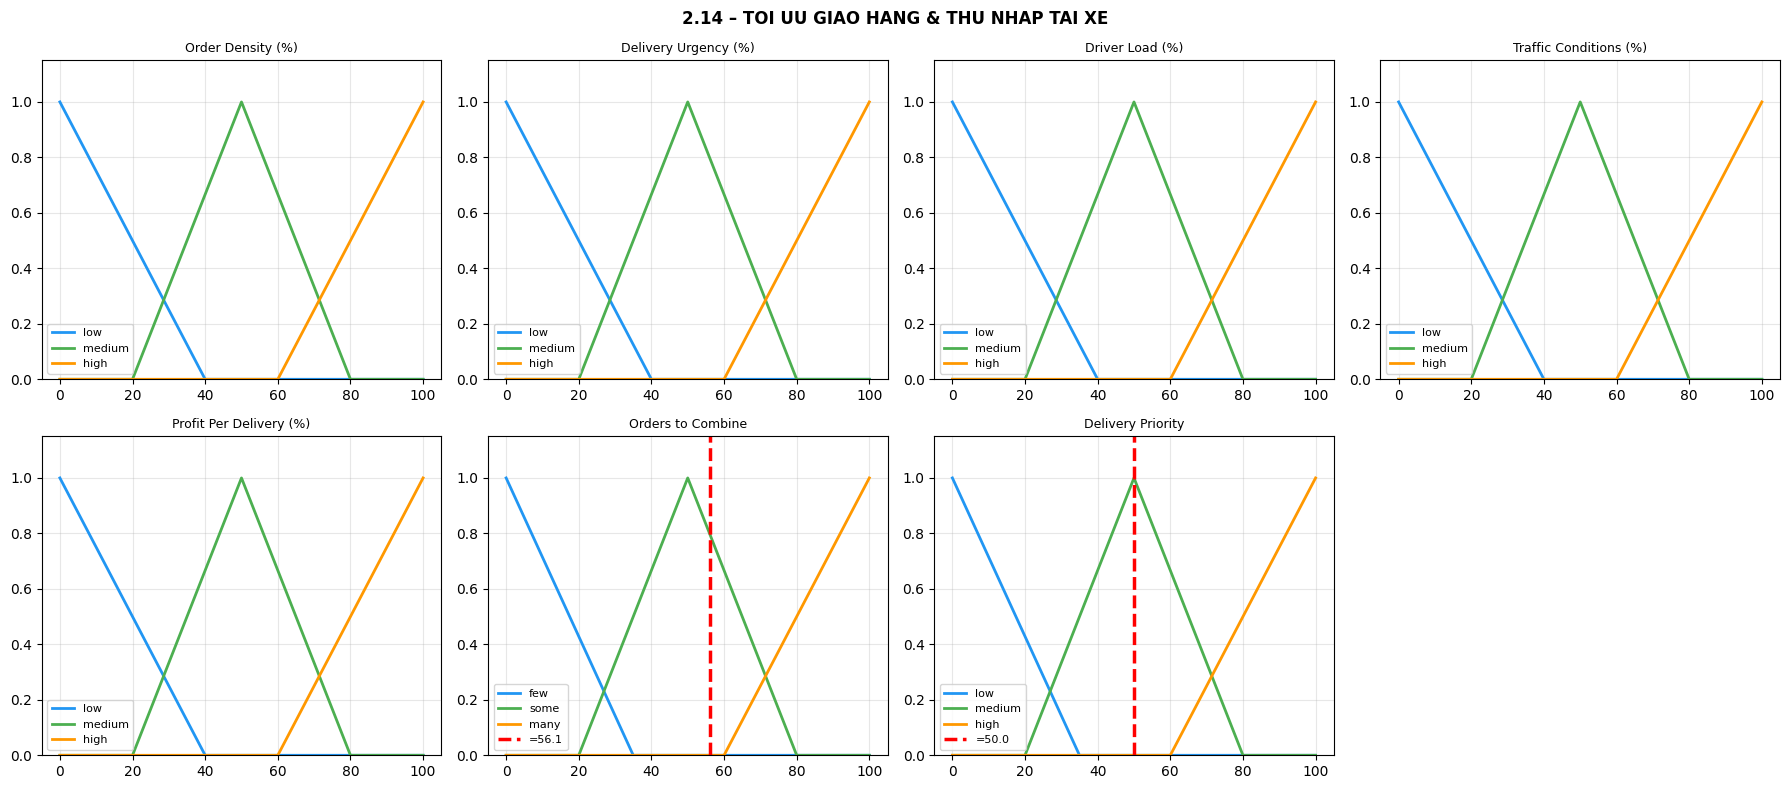

In [2]:

!pip install scikit-fuzzy -q

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

order_density = ctrl.Antecedent(np.arange(0, 101, 1), 'order_density')

urgency = ctrl.Antecedent(np.arange(0, 101, 1), 'urgency')

driver_load = ctrl.Antecedent(np.arange(0, 101, 1), 'driver_load')

traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')

profit_per_delivery = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_per_delivery')

orders_combine = ctrl.Consequent(np.arange(0, 101, 1), 'orders_combine')

delivery_priority = ctrl.Consequent(np.arange(0, 101, 1), 'delivery_priority')

for var in [order_density, urgency, driver_load, traffic, profit_per_delivery]:
    var['low']    = fuzz.trimf(var.universe, [0,  0,  40])
    var['medium'] = fuzz.trimf(var.universe, [20, 50, 80])
    var['high']   = fuzz.trimf(var.universe, [60, 100, 100])

orders_combine['few']    = fuzz.trimf(orders_combine.universe, [0,  0,  35])
orders_combine['some']   = fuzz.trimf(orders_combine.universe, [20, 50, 80])
orders_combine['many']   = fuzz.trimf(orders_combine.universe, [60, 100, 100])

delivery_priority['low']   = fuzz.trimf(delivery_priority.universe, [0,  0,  35])
delivery_priority['medium']= fuzz.trimf(delivery_priority.universe, [20, 50, 80])
delivery_priority['high']  = fuzz.trimf(delivery_priority.universe, [60, 100, 100])

rules = [
    ctrl.Rule(order_density['high'] & traffic['low'],                                orders_combine['many']),

    ctrl.Rule(order_density['high'] & driver_load['medium'],                         orders_combine['some']),

    ctrl.Rule(driver_load['high']   & order_density['high'] & traffic['high'],       orders_combine['some']),

    ctrl.Rule(order_density['high'] & traffic['medium'],                             orders_combine['many']),

    ctrl.Rule(traffic['high']       & profit_per_delivery['high'],                   orders_combine['few']),

    ctrl.Rule(driver_load['low']    & order_density['high'],                         orders_combine['many']),

    ctrl.Rule(urgency['high']       & driver_load['high'],                           orders_combine['few']),

    ctrl.Rule(urgency['high']       & profit_per_delivery['high'],                   delivery_priority['high']),

    ctrl.Rule(urgency['medium']     & order_density['low'],                          delivery_priority['medium']),

    ctrl.Rule(urgency['low']        & profit_per_delivery['low'],                    delivery_priority['low']),

    ctrl.Rule(profit_per_delivery['high'] & traffic['low'],                          delivery_priority['high']),

    ctrl.Rule(traffic['high']       & urgency['medium'],                             delivery_priority['medium']),
]

ctrl214 = ctrl.ControlSystem(rules)
sim214  = ctrl.ControlSystemSimulation(ctrl214)

inp_order_density       = 80
inp_urgency             = 60
inp_driver_load         = 40
inp_traffic             = 70
inp_profit_per_delivery = 65

sim214.input['order_density']       = inp_order_density
sim214.input['urgency']             = inp_urgency
sim214.input['driver_load']         = inp_driver_load
sim214.input['traffic']             = inp_traffic
sim214.input['profit_per_delivery'] = inp_profit_per_delivery
sim214.compute()

out_combine  = sim214.output['orders_combine']
out_priority = sim214.output['delivery_priority']

if out_combine <= 33:
    combine_level = "It (giao tung don)"
elif out_combine <= 66:
    combine_level = "Mot so (2-3 don)"
else:
    combine_level = "Nhieu (3+ don)"

if out_priority <= 33:
    priority_level = "Thap (giao sau)"
elif out_priority <= 66:
    priority_level = "Trung binh"
else:
    priority_level = "Cao (uu tien ngay)"

print("=" * 55)
print("   2.14 – TOI UU GIAO HANG & THU NHAP TAI XE")
print("=" * 55)
print(f"  Mat do don hang      : {inp_order_density}%")
print(f"  Muc do khan cap      : {inp_urgency}%")
print(f"  Tai trong tai xe     : {inp_driver_load}%")
print(f"  Tinh trang giao thong: {inp_traffic}%  (30km/h = ~70)")
print(f"  Loi nhuan moi don    : {inp_profit_per_delivery}%")
print(f"\n  >> Ket hop don hang  : {out_combine:.1f}/100 → {combine_level}")
print(f"  >> Uu tien giao hang : {out_priority:.1f}/100 → {priority_level}")
print("=" * 55)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('2.14 – TOI UU GIAO HANG & THU NHAP TAI XE', fontsize=12, fontweight='bold')
clrs = ['#2196F3','#4CAF50','#FF9800']

vars_cfg = [
    (order_density,       'Order Density (%)'),
    (urgency,             'Delivery Urgency (%)'),
    (driver_load,         "Driver Load (%)"),
    (traffic,             'Traffic Conditions (%)'),
    (profit_per_delivery, 'Profit Per Delivery (%)'),
    (orders_combine,      'Orders to Combine'),
    (delivery_priority,   'Delivery Priority'),
]

for idx, (ax, (var, title)) in enumerate(zip(axes.flatten(), vars_cfg)):
    for i, lbl in enumerate(var.terms):
        ax.plot(var.universe, var[lbl].mf, label=lbl, lw=2, color=clrs[i % 3])
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8); ax.grid(alpha=.3); ax.set_ylim(0, 1.15)

axes[1][1].axvline(x=out_combine, color='red', linestyle='--', lw=2.5,
                   label=f'={out_combine:.1f}')
axes[1][1].legend(fontsize=8)

axes[1][2].axvline(x=out_priority, color='red', linestyle='--', lw=2.5,
                   label=f'={out_priority:.1f}')
axes[1][2].legend(fontsize=8)

axes[1][3].axis('off')

plt.tight_layout()
plt.show()